<a href="https://colab.research.google.com/github/Tahir-MD/Elevo_NLP_Intership/blob/main/Elevvo_NLP_Intership_Task_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
import nltk
from nltk.corpus import stopwords
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [35]:
df = pd.read_csv('BBC news dataset.csv')
print(df.head())
print(df.shape)

   Unnamed: 0                                        description  \
0           0  chelsea sack mutu  chelsea have sacked adrian ...   
1           1  record fails to lift lacklustre meet  yelena i...   
2           2  edu describes tunnel fracas  arsenals edu has ...   
3           3  ogara revels in ireland victory  ireland flyha...   
4           4  unclear future for striker baros  liverpool fo...   

                                                tags  
0  sports, stamford bridge, football association,...  
1  sports, madrid, birmingham, france, scotland, ...  
2  sports, derby, brazil, tunnel fracasedu, food,...  
3  sports, bbc, united kingdom, ireland, brian o'...  
4  sports, liverpool, daily sport, millennium sta...  
(2410, 3)


In [36]:
if 'description' in df.columns:
    df['text'] = df['description']
elif 'title' in df.columns and 'description' in df.columns:
    df['text'] = df['title'] + ' ' + df['description']
elif 'news' in df.columns:
    df['text'] = df['news']
else:
    df['text'] = df.iloc[:, 0]

In [37]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 10]
df = df.reset_index(drop=True)

In [38]:
vectorizer = CountVectorizer(max_df=0.9, min_df=5, max_features=1000)
dtm = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()
print(f"Documents: {dtm.shape[0]}, Words: {dtm.shape[1]}")

Documents: 2410, Words: 1000


In [39]:
lda = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=100)
lda.fit(dtm)

LatentDirichletAllocation(max_iter=100, n_components=5, random_state=42)

In [40]:
print("LDA Topics:")
for idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {idx+1}: {', '.join(top_words)}")

LDA Topics:
Topic 1: said, game, first, world, win, time, one, play, last, england
Topic 2: said, music, new, would, company, also, firm, deal, show, bbc
Topic 3: said, year, film, best, market, last, also, sales, years, growth
Topic 4: said, people, technology, mobile, also, users, could, one, new, digital
Topic 5: said, would, government, people, labour, election, could, also, party, blair


In [41]:
topic_results = lda.transform(dtm)
df['topic'] = topic_results.argmax(axis=1)
print("\nTopic Distribution:")
print(df['topic'].value_counts().sort_index())


Topic Distribution:
topic
0    539
1    282
2    511
3    540
4    538
Name: count, dtype: int64


In [14]:
nmf = NMF(n_components=5, random_state=42)
nmf.fit(dtm)
print("NMF Topics:")
display_topics(nmf, feature_names)

NMF Topics:
Topic 1: bank, government, could, business, economy, year, also, united, would, said
Topic 2: phones, music, media, phone, said, software, digital, people, mobile, technology
Topic 3: first, playing, rugby, play, gaming, world, online, time, games, game
Topic 4: last, director, award, british, years, song, awards, film, best, music
Topic 5: would, minister, brown, kingdom, united, government, election, blair, party, labour



In [43]:
print("\nLDA vs NMF Comparison (Top 5 words):")
for i in range(5):
    lda_idx = lda.components_[i].argsort()[-5:][::-1]
    nmf_idx = nmf.components_[i].argsort()[-5:][::-1]
    lda_words = [feature_names[j] for j in lda_idx]
    nmf_words = [feature_names[j] for j in nmf_idx]
    print(f"\nTopic {i+1}:")
    print(f"LDA: {lda_words}")
    print(f"NMF: {nmf_words}")


LDA vs NMF Comparison (Top 5 words):

Topic 1:
LDA: ['said', 'game', 'first', 'world', 'win']
NMF: ['people', 'mobile', 'technology', 'music', 'digital']

Topic 2:
LDA: ['said', 'music', 'new', 'would', 'company']
NMF: ['said', 'would', 'also', 'year', 'new']

Topic 3:
LDA: ['said', 'year', 'film', 'best', 'market']
NMF: ['best', 'music', 'song', 'years', 'awards']

Topic 4:
LDA: ['said', 'people', 'technology', 'mobile', 'also']
NMF: ['game', 'games', 'time', 'world', 'play']

Topic 5:
LDA: ['said', 'would', 'government', 'people', 'labour']
NMF: ['would', 'labour', 'government', 'election', 'party']


In [44]:
print("\nSample documents per topic:")
for topic_num in range(5):
    print(f"\n--- Topic {topic_num+1} ---")
    topic_docs = df[df['topic'] == topic_num]['text'].head(2)
    for i, doc in enumerate(topic_docs):
        print(f"{i+1}. {doc[:200]}...")


Sample documents per topic:

--- Topic 1 ---
1. chelsea sack mutu  chelsea have sacked adrian mutu after he failed a drugs test  the yearold tested positive for a banned substance  which he later denied was cocaine  in october chelsea have decided ...
2. record fails to lift lacklustre meet  yelena isinbayeva may have produced another world pole vault record but her achievement could not hide the fact it was not the best meet we have ever seen in birm...

--- Topic 2 ---
1. ronaldo considering new contract  manchester united winger cristiano ronaldo said he is close to agreeing to a new contract at old trafford  the portugal star who joined in august  on a fiveyeardeal i...
2. fa charges liverpool and millwall  liverpool and millwall have been charged by the football association over crowd trouble during their carling cup match on  october  millwall who lost the match  have...

--- Topic 3 ---
1. henry tipped for fifa award  fifa president sepp blatter hopes arsenals thierry henry wil

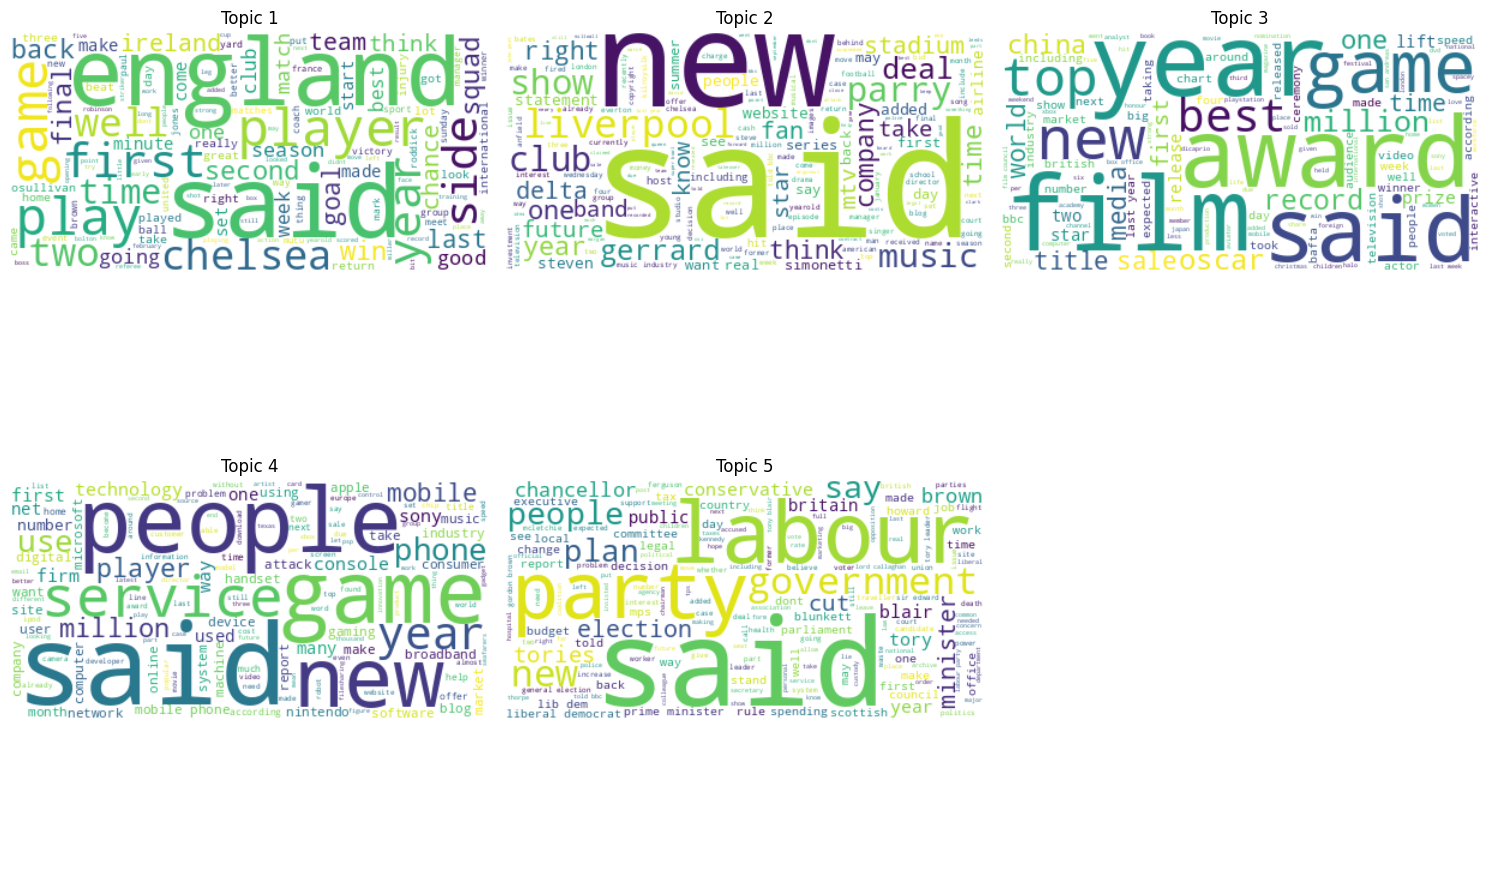

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for topic_num in range(5):
    topic_text = ' '.join(df[df['topic'] == topic_num]['clean_text'].head(30))
    if len(topic_text) > 0:
        wordcloud = WordCloud(width=400, height=200, background_color='white').generate(topic_text)
        axes[topic_num].imshow(wordcloud, interpolation='bilinear')
        axes[topic_num].axis('off')
        axes[topic_num].set_title(f'Topic {topic_num+1}')

axes[5].axis('off')
plt.tight_layout()
plt.show()

In [46]:
topic_words_df = pd.DataFrame()
for idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    topic_words_df[f'Topic_{idx+1}'] = top_words

print("Topic Words Summary:")
print(topic_words_df)

Topic Words Summary:
   Topic_1  Topic_2 Topic_3     Topic_4     Topic_5
0     said     said    said        said        said
1     game    music    year      people       would
2    first      new    film  technology  government
3    world    would    best      mobile      people
4      win  company  market        also      labour
5     time     also    last       users    election
6      one     firm    also       could       could
7     play     deal   sales         one        also
8     last     show   years         new       party
9  england      bbc  growth     digital       blair


In [47]:
df[['text', 'topic']].to_csv('bbc_topics_results.csv', index=False)
print("Results saved to bbc_topics_results.csv")

Results saved to bbc_topics_results.csv


In [48]:
for topic_num in range(5):
    print(f"\nTopic {topic_num+1} - Top 15 words with weights:")
    topic_word_weights = []
    for i, word in enumerate(feature_names):
        if lda.components_[topic_num][i] > 0.1:
            topic_word_weights.append((word, lda.components_[topic_num][i]))

    topic_word_weights.sort(key=lambda x: x[1], reverse=True)
    for word, weight in topic_word_weights[:15]:
        print(f"  {word}: {weight:.3f}")


Topic 1 - Top 15 words with weights:
  said: 921.877
  game: 918.833
  first: 608.401
  world: 557.184
  win: 537.872
  time: 525.056
  one: 514.702
  play: 454.185
  last: 451.245
  england: 451.072
  two: 450.265
  back: 402.812
  good: 383.439
  games: 373.740
  players: 373.224

Topic 2 - Top 15 words with weights:
  said: 1068.122
  music: 616.487
  new: 477.148
  would: 468.455
  company: 458.693
  also: 411.455
  firm: 367.148
  deal: 351.335
  show: 349.549
  bbc: 278.660
  one: 274.209
  group: 255.314
  band: 218.187
  court: 215.795
  former: 200.942

Topic 3 - Top 15 words with weights:
  said: 1152.559
  year: 1007.146
  film: 776.325
  best: 608.725
  market: 497.213
  last: 476.078
  also: 470.316
  sales: 468.322
  years: 450.527
  growth: 436.537
  bank: 359.186
  economy: 349.604
  new: 349.022
  awards: 331.189
  number: 326.939

Topic 4 - Top 15 words with weights:
  said: 1900.702
  people: 1393.846
  technology: 740.193
  mobile: 663.196
  also: 635.751
  users: 